#### **Setup**

In [31]:
import polars as pl 
import matplotlib.pyplot as plt
from scipy.stats import skew
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

In [32]:
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_hide_dataframe_shape(True)

polars.config.Config

In [33]:
df=pl.read_parquet("cleaned_data.parquet")


#### **Inspect Data**

In [34]:
df.shape

(355376, 6)

In [35]:
df.columns

['diabetes', 'age', 'bmi', 'sex', 'hypertension', 'total_activity']

In [36]:
df.is_duplicated().sum()

236817

> Duplicate rows are retained because respondents can share identical predictors

In [38]:
df.schema

Schema([('diabetes', Float64),
        ('age', Float64),
        ('bmi', Float64),
        ('sex', Float64),
        ('hypertension', Float64),
        ('total_activity', Float64)])

In [39]:
# Unique values / ranges of key columns
print("age min:", df["age"].min())
print("age max:", df["age"].max())
print("bmi min:", df["bmi"].min())
print("bmi max:", df["bmi"].max())
print("diabetes:", df["diabetes"].unique().sort())
print("sex:", df["sex"].unique().sort())
print("hypertension:", df["hypertension"].unique().sort())
print("total_activity:", df["total_activity"].unique().sort())


age min: 18.0
age max: 80.0
bmi min: 12.02
bmi max: 98.43
diabetes: shape: (2,)
Series: 'diabetes' [f64]
[
	0.0
	1.0
]
sex: shape: (2,)
Series: 'sex' [f64]
[
	0.0
	1.0
]
hypertension: shape: (3,)
Series: 'hypertension' [f64]
[
	null
	0.0
	1.0
]
total_activity: shape: (3,)
Series: 'total_activity' [f64]
[
	null
	0.0
	1.0
]


#### **Create BMI And Age Categories** 

In [57]:
df = df.with_columns(
    pl.when(pl.col("age").is_null()).then(None)
    .when(pl.col("age") < 40).then(pl.lit("<40"))
    .when(pl.col("age") < 50).then(pl.lit("40-49"))
    .when(pl.col("age") < 60).then(pl.lit("50-59"))
    .otherwise(pl.lit("60+"))
    .alias("age_category"),

    pl.when(pl.col("bmi").is_null()).then(None)
    .when(pl.col("bmi") < 25).then(pl.lit("<25"))
    .when(pl.col("bmi") < 30).then(pl.lit("25-29.9"))
    .when(pl.col("bmi") < 40).then(pl.lit("30-39.9"))
    .otherwise(pl.lit("40+"))
    .alias("bmi_category")
)

predictors = [
    "age_category",
    "bmi_category",
    "sex",
    "hypertension",
    "total_activity"
]

#### **Split Data for Training**

In [41]:
X = df.drop("diabetes")
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = X_train.with_columns(y_train)
train_df.shape


(284300, 8)

#### **Outcome Distribution** 


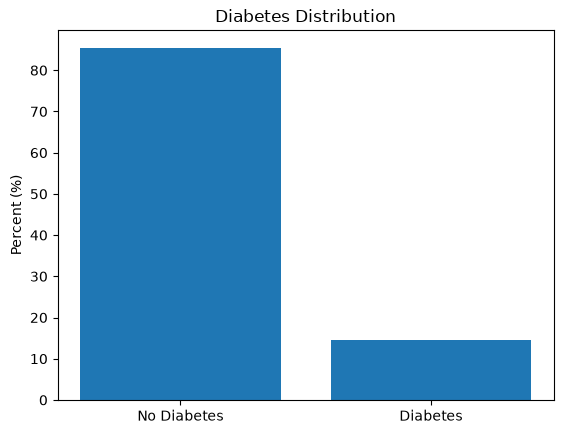

The proportion of participants with diabetes: 0.1458353851565248


In [42]:
diabetes_prop = train_df["diabetes"].value_counts(normalize=True).sort("diabetes")

plt.bar(
    ["No Diabetes", "Diabetes"],
    diabetes_prop["proportion"] * 100
)

plt.ylabel("Percent (%)")
plt.title("Diabetes Distribution")
plt.show()
print(f"The proportion of participants with diabetes: {diabetes_prop['proportion'][1]}")

> Diabetes is unbalanced

#### **Univariate Analysis**

*Summary Statistics*

In [43]:
summary_table = pl.DataFrame({
    "Variable": [
        "Age",
        "BMI",
        "Diabetes",
        "Sex",
        "Hypertension",
        "Physical inactivity",
    ],
    "Mean (SD), %": [
        f"{train_df['age'].mean():.2f} ({train_df['age'].std():.2f})",
        f"{train_df['bmi'].mean():.2f} ({train_df['bmi'].std():.2f})",
        f"{train_df['diabetes'].mean() * 100:.1f}%",
        f"{train_df['sex'].mean() * 100:.1f}%",
        f"{train_df['hypertension'].mean() * 100:.1f}%",
        f"{train_df['total_activity'].mean() * 100:.1f}%",
    ]
})

print(summary_table)



┌─────────────────────┬───────────────┐
│ Variable            ┆ Mean (SD), %  │
╞═════════════════════╪═══════════════╡
│ Age                 ┆ 55.79 (18.36) │
│ BMI                 ┆ 28.48 (6.54)  │
│ Diabetes            ┆ 14.6%         │
│ Sex                 ┆ 52.8%         │
│ Hypertension        ┆ 41.8%         │
│ Physical inactivity ┆ 76.8%         │
└─────────────────────┴───────────────┘


*Distribution of Age and BMI*

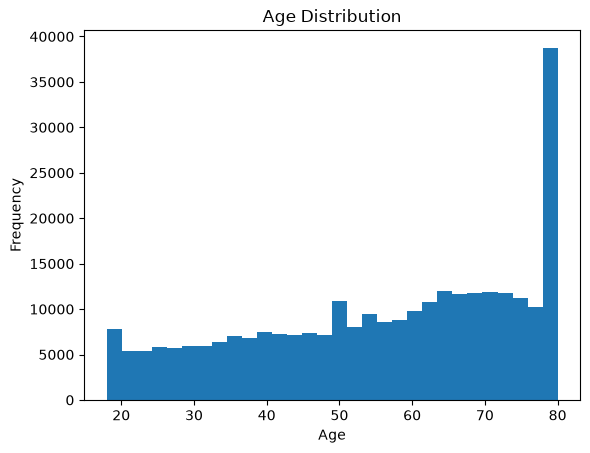

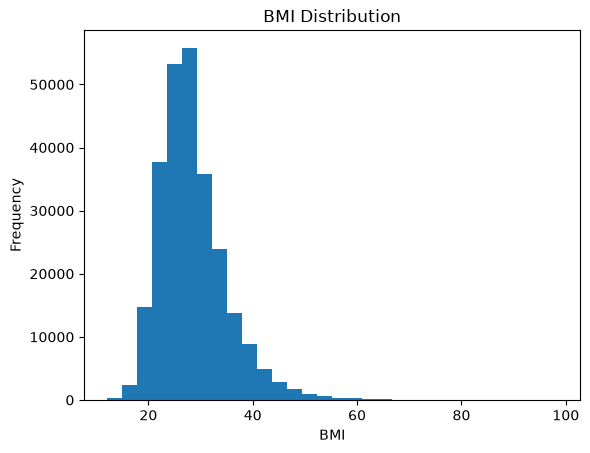

In [44]:
# Age
plt.hist(train_df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

# BMI
plt.hist(train_df["bmi"], bins=30)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("BMI Distribution")
plt.show()

*Boxplots*

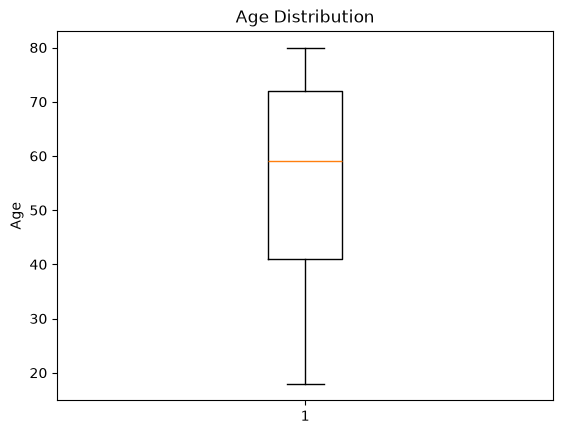

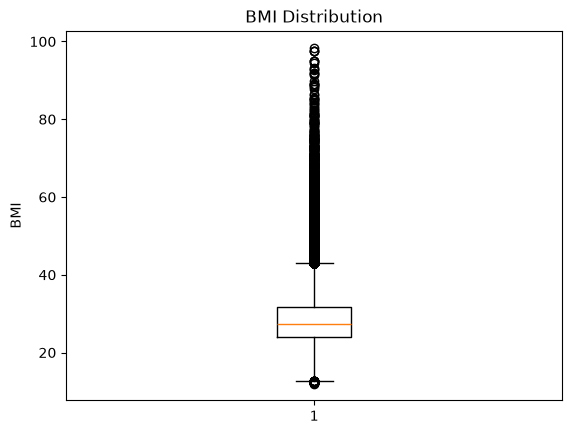

In [45]:
# Age
plt.boxplot(train_df["age"].drop_nulls())
plt.ylabel("Age")
plt.title("Age Distribution")
plt.show()

# BMI
plt.boxplot(train_df["bmi"].drop_nulls())
plt.ylabel("BMI")
plt.title("BMI Distribution")
plt.show()

> Outliers are biologically plausible, will keep

*Proportion Table for Age and BMI Groups*

In [46]:
age_table = (
    train_df
    .group_by("age_category")
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100)
        .round(1)
        .alias("Percent (%)")
    )
    .sort(
        pl.col("age_category").replace({
            "<40": 1,
            "40-49": 2,
            "50-59": 3,
            "60+": 4
        })
    )
    .select(
        pl.col("age_category").alias("Age Group"),
        "Percent (%)"
    )
)

print(age_table)

┌───────────┬─────────────┐
│ Age Group ┆ Percent (%) │
╞═══════════╪═════════════╡
│ <40       ┆ 23.1        │
│ 40-49     ┆ 12.9        │
│ 50-59     ┆ 14.9        │
│ 60+       ┆ 49.2        │
└───────────┴─────────────┘


In [47]:
bmi_table = (
    train_df
    .group_by("bmi_category")
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100)
        .round(1)
        .alias("Percent (%)")
    )
    .sort(
        pl.col("bmi_category").replace({
            "<25": 1,
            "25-29.9": 2,
            "30-39.9": 3,
            "40+": 4
        })
    )
    .select(
        pl.col("bmi_category").alias("BMI Group"),
        "Percent (%)"
    )
)

print(bmi_table)

┌───────────┬─────────────┐
│ BMI Group ┆ Percent (%) │
╞═══════════╪═════════════╡
│ null      ┆ 9.1         │
│ <25       ┆ 28.6        │
│ 25-29.9   ┆ 32.3        │
│ 30-39.9   ┆ 25.0        │
│ 40+       ┆ 5.0         │
└───────────┴─────────────┘


#### **Missingness**

####

Missingness by predictor, stratified by diabetes

In [ ]:


for var in predictors:
    missing_table = (
        train_df
        .group_by("diabetes")
        .agg(
            (pl.col(var).is_null().mean() * 100)
            .round(1)
            .alias("Missing (%)")
        )
        .sort("diabetes")
    )

    print(var)
    print(missing_table)

age_category
┌──────────┬─────────────┐
│ diabetes ┆ Missing (%) │
╞══════════╪═════════════╡
│ 0.0      ┆ 0.0         │
│ 1.0      ┆ 0.0         │
└──────────┴─────────────┘
bmi_category
┌──────────┬─────────────┐
│ diabetes ┆ Missing (%) │
╞══════════╪═════════════╡
│ 0.0      ┆ 9.2         │
│ 1.0      ┆ 8.2         │
└──────────┴─────────────┘
sex
┌──────────┬─────────────┐
│ diabetes ┆ Missing (%) │
╞══════════╪═════════════╡
│ 0.0      ┆ 0.0         │
│ 1.0      ┆ 0.0         │
└──────────┴─────────────┘
hypertension
┌──────────┬─────────────┐
│ diabetes ┆ Missing (%) │
╞══════════╪═════════════╡
│ 0.0      ┆ 1.2         │
│ 1.0      ┆ 1.1         │
└──────────┴─────────────┘
total_activity
┌──────────┬─────────────┐
│ diabetes ┆ Missing (%) │
╞══════════╪═════════════╡
│ 0.0      ┆ 0.2         │
│ 1.0      ┆ 0.4         │
└──────────┴─────────────┘


Does diabetes prevalence differ between complete and incomplete cases? 

In [56]:
missing_compare = (
    train_df
    .with_columns(
        pl.any_horizontal(
            pl.col(predictors).is_null()
        ).alias("incomplete")
    )
    .group_by("incomplete")
    .agg(
        pl.len().alias("n"),
        (pl.col("diabetes").mean() * 100)
        .round(1)
        .alias("Diabetes (%)")
    )
)

print(missing_compare)

┌────────────┬────────┬──────────────┐
│ incomplete ┆ n      ┆ Diabetes (%) │
╞════════════╪════════╪══════════════╡
│ false      ┆ 255103 ┆ 14.7         │
│ true       ┆ 29197  ┆ 13.4         │
└────────────┴────────┴──────────────┘


In [ ]:
print(train_df.shape)
print(train_df.drop_nulls().shape)

(284300, 8)
(255103, 8)


Will dropp incomplete cases, although is a small difference in diabetes prevalence among complete and incomplete cases and it'll reduce training data by ~9%

#### **Predictor x Outcome** 

Proportions

In [81]:
table = train_df.pivot(
    values="diabetes",
    index="age_category",
    on="diabetes",
    aggregate_function="len"
)

table = table.with_columns(
    (
        pl.col("0.0", "1.0")
        / pl.sum_horizontal("0.0", "1.0")
        * 100
    ).round(1)
)

table = table.rename({
    "0.0":"No Diabetes",
    "1.0":"Diabetes"
})

chi2, p, dof, expected = chi2_contingency(
    table.select("0", "1").to_numpy()
)

print(table)
print("p-value", p)



ColumnNotFoundError: unable to find column "0"; valid columns: ["age_category", "No Diabetes", "Diabetes"]

diabetes,age,bmi,sex,hypertension,total_activity,age_category,bmi_category
0.0,71.0,30.79,1.0,1.0,1.0,"""60+""","""30-39.9"""
1.0,80.0,19.66,1.0,1.0,1.0,"""60+""","""<25"""
1.0,68.0,33.2,1.0,1.0,0.0,"""60+""","""30-39.9"""
1.0,80.0,29.8,0.0,1.0,0.0,"""60+""","""25-29.9"""
0.0,64.0,28.46,0.0,0.0,1.0,"""60+""","""25-29.9"""
